# DOM-Graph RAG — vue d'ensemble du pipeline

Ce notebook fait tourner **chaque étape** du pipeline de bout en bout, sur une
petite page HTML locale (`tests/fixtures/sample_page.html`) : pas de réseau,
pas de VLM réel requis, tout se lit en quelques secondes. Le but est de
**voir** ce qui se passe à chaque phase, pas de produire un vrai jeu de
données — pour ça, voir `scripts/build_dataset.py` (à grande échelle, sur
Wikipedia) et `notebooks/01_pipeline_playground.ipynb` (bac à sable sur une
vraie page, graphe interactif pyvis).

Correspondance avec les phases du README :

| Phase | Ce qu'elle fait | Module |
|---|---|---|
| 1a/1b | Rendu de la page + extraction DOM | `src/dom_extraction.py` |
| 1c | Tuilage adaptatif + patching | `src/tiling.py` |
| 1d | Construction du graphe (5 relations) | `src/graph_builder.py` |
| 1e | Sectionnement des pages trop longues / corpus multi-pages | `src/sectioning.py`, `src/corpus_builder.py` |
| 2a | Génération QA synthétique par tuile | `src/qa_generation.py` |
| 2b | Hard-negative mining | `src/hard_negative_mining.py` |
| 2c | Dataset contrastif PyTorch | `src/contrastive_dataset.py` |
| 2d | Fine-tuning LoRA du lecteur | `src/lora_finetune.py` |
| 3 | Contrôleur d'évidence en ligne | `src/evidence_controller.py` |

In [1]:
import io
import json
import re
import shutil
import sys
import tempfile
from collections import Counter
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from PIL import Image

from src.config import MAX_PAGE_HEIGHT_BEFORE_SPLIT, MAX_TILE_HEIGHT
from src.dom_extraction import extract_dom_elements_async
from src.tiling import build_tiles
from src.graph_builder import build_graph, graph_to_xml
from src.sectioning import is_oversized_page, split_into_sections
from src.visualization import plot_graph, plot_page_overlay
from src.qa_generation import append_tiles_manifest, generate_qa_pair_for_tile, save_tile_images
from src.hard_negative_mining import mine_hard_negatives, save_contrastive_examples
from src.contrastive_dataset import ContrastiveTileDataset, contrastive_collate_fn
from src.evidence_controller import EvidenceControllerConfig, collect_evidence, run_evidence_controller, state_counts

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

FIXTURE_URL = (PROJECT_ROOT / "tests" / "fixtures" / "sample_page.html").as_uri()
print("Page de démonstration :", FIXTURE_URL)

AttributeError: module 'numpy._globals' has no attribute '_signature_descriptor'

ImportError: cannot load module more than once per process

/opt/anaconda3/lib/python3.11/site-packages/torch/_subclasses/functional_tensor.py:368: UserWarning: Failed to initialize NumPy: cannot load module more than once per process (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:84.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


ImportError: cannot load module more than once per process

Page de démonstration : file:///Users/alexisfirome/Desktop/PDM/domgraph-rag/tests/fixtures/sample_page.html


## Étape 1 — Extraction DOM (Phase 1a/1b)

Playwright charge la page en headless, retire le bruit d'interface
(`nav`, `footer`, ... — cf. `NOISE_SELECTORS`), prend une capture d'écran
pleine page, puis mesure la bounding box absolue (x, y, largeur, hauteur) de
chaque élément pertinent (`ELEMENT_TAGS` : titres, paragraphes, tables,
listes, images...).

14 éléments DOM extraits (nav/footer déjà retirés)
Balises rencontrées : ['h1', 'h2', 'h3', 'img', 'p', 'table', 'ul']
  <h1>  698x36px  —  "Retrieval-Augmented Generation (page d'exemple)"
  <p>  960x17px  —  'La génération augmentée par récupération (RAG) est une techn'
  <p>  959x17px  —  'Elle permet de fournir au modèle un contexte externe pertine'
  <h2>  202x26px  —  'Approches visuelles'
  <p>  930x17px  —  'Certaines approches récentes, comme PixelRAG, proposent de c'
  <table>  402x90px  —  'Système\tGranularité\tBenchmark principal\nText RAG\tChunk de te'

Capture d'écran pleine page (bruit d'interface déjà retiré) :


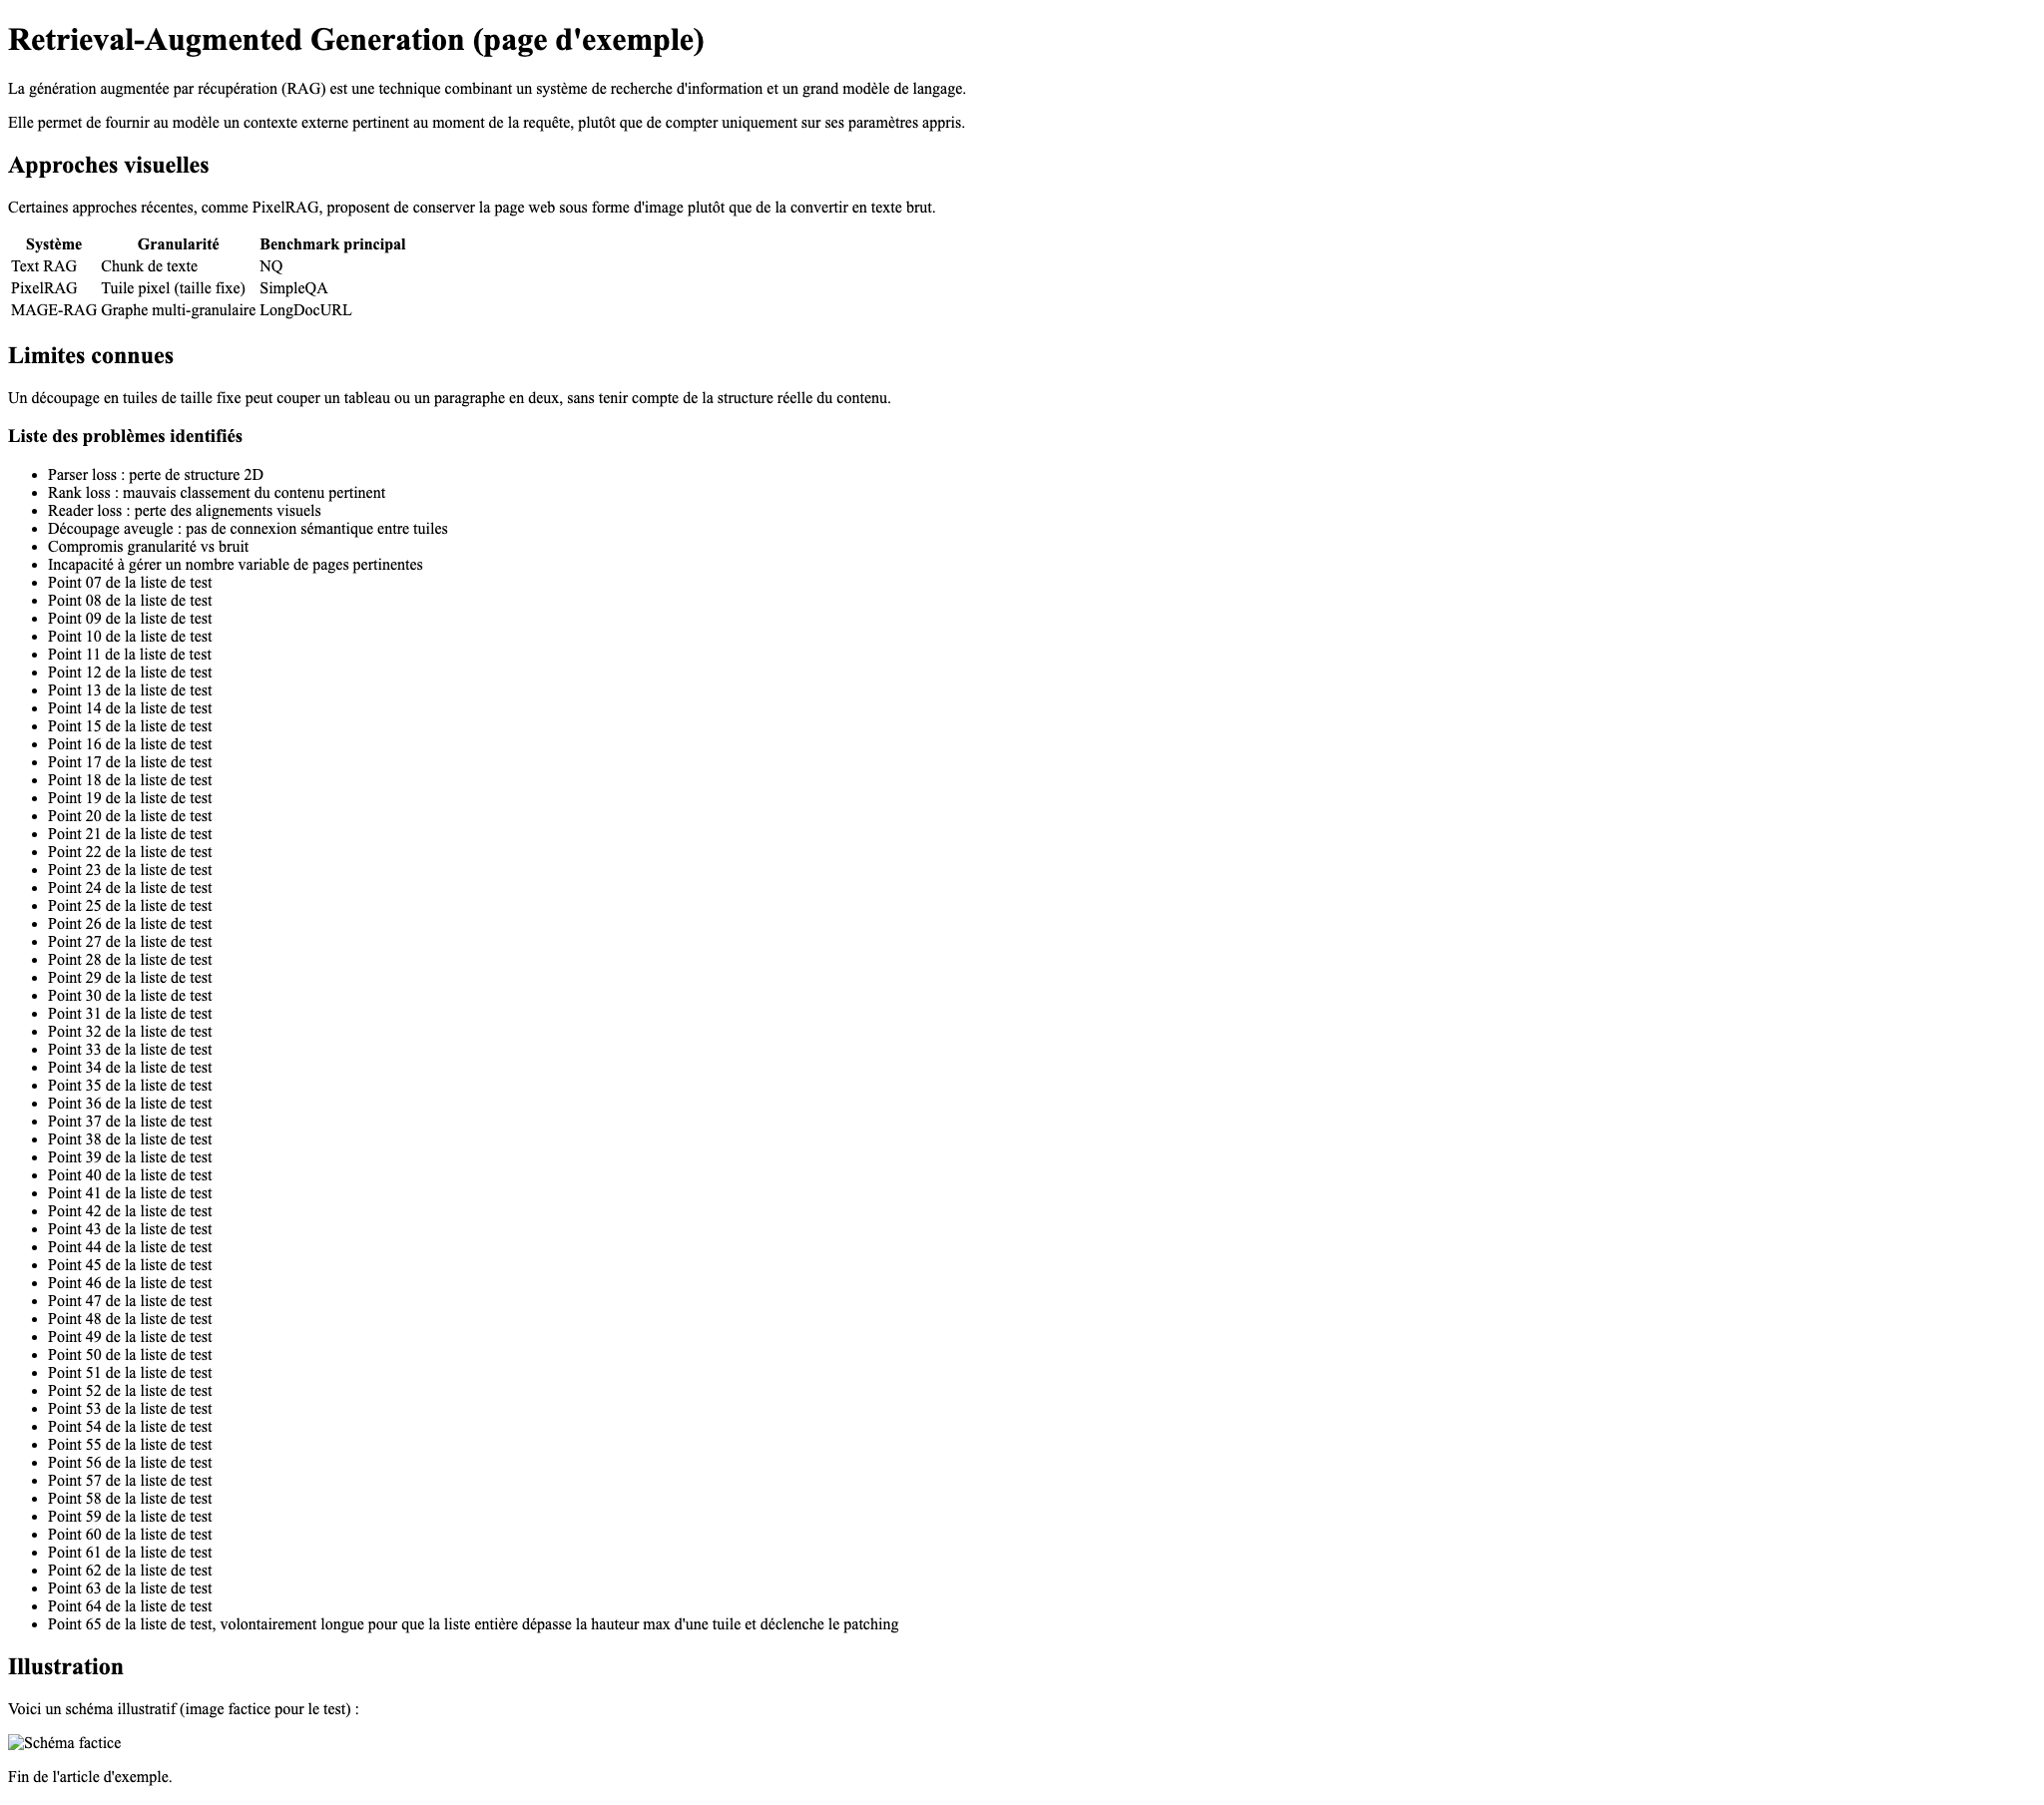

In [2]:
elements, screenshot = await extract_dom_elements_async(FIXTURE_URL, wait_until="load")

print(f"{len(elements)} éléments DOM extraits (nav/footer déjà retirés)")
print("Balises rencontrées :", sorted({e.tag for e in elements}))
for e in elements[:6]:
    print(f"  <{e.tag}>  {e.width:.0f}x{e.height:.0f}px  —  {e.text_preview[:60]!r}")

print("\nCapture d'écran pleine page (bruit d'interface déjà retiré) :")
Image.open(io.BytesIO(screenshot)).convert("RGB")

## Étape 2 — Tuilage adaptatif et patching (Phase 1c)

`build_tiles` transforme les éléments DOM bruts en tuiles visuelles :
éléments imbriqués élagués, petits éléments voisins fusionnés (hauteur <
`MIN_TILE_HEIGHT`), éléments qui se chevauchent tuilés ensemble, éléments trop
hauts découpés (« patching »). Contrairement à PixelRAG, la découpe suit donc
le contenu réel plutôt qu'une grille de hauteur fixe.

14 éléments DOM -> 8 tuiles

  tile_0000  tag=h1+p          960x  75px  "Retrieval-Augmented Generation (page d'exemple) La"
  tile_0001  tag=merged        959x  17px  'Elle permet de fournir au modèle un contexte exter'
  tile_0002  tag=h2+p          929x  63px  'Approches visuelles Certaines approches récentes, '
  tile_0003  tag=table         401x  90px  'Système\tGranularité\tBenchmark principal\nText RAG\tC'
  tile_0004  tag=h2+p          885x  63px  'Limites connues Un découpage en tuiles de taille f'
  tile_0005  tag=h3+ul         892x1209px  'Liste des problèmes identifiés Parser loss : perte'
  tile_0006  tag=h2+p          352x  63px  'Illustration Voici un schéma illustratif (image fa'
  tile_0007  tag=merged        164x  51px  " Fin de l'article d'exemple."


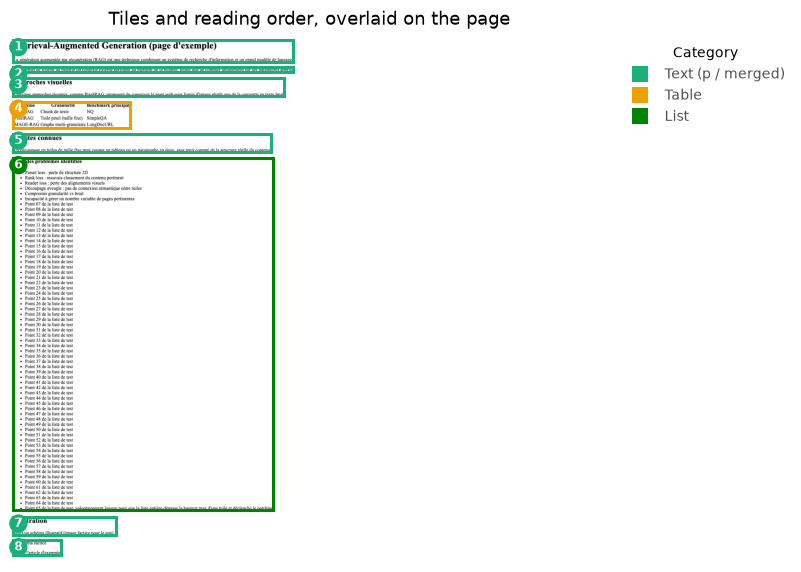

In [3]:
tiles = build_tiles(elements, screenshot)
print(f"{len(elements)} éléments DOM -> {len(tiles)} tuiles\n")
for t in tiles:
    print(f"  {t.id:10s} tag={t.dom_tag:12s} {t.width:4d}x{t.height:4d}px  {t.text_preview[:50]!r}")

fig, ax = plt.subplots(figsize=(7, 9))
plot_page_overlay(tiles, screenshot, ax=ax)
plt.show()

In [4]:
# Le patching : un max_tile_height réduit force la longue <ul> du fixture
# (65 items, volontairement longue) à être découpée en plusieurs sous-tuiles.
patched_tiles = build_tiles(elements, screenshot, max_tile_height=300)
ul_tiles = [t for t in patched_tiles if "ul" in t.dom_tag.split("+")]
print(f"max_tile_height=300px (production : {MAX_TILE_HEIGHT}px) "
      f"-> la longue <ul> est découpée en {len(ul_tiles)} sous-tuiles (patching)")

max_tile_height=300px (production : 2048px) -> la longue <ul> est découpée en 5 sous-tuiles (patching)


## Étape 3 — Construction du graphe (Phase 1d)

`build_graph` construit un graphe à 2 niveaux (1 noeud « page » + N noeuds
« élément », un par tuile) et instancie les relations de MAGE-RAG :
`contains`, `reading_order` (ordre de lecture spatial, pas l'ordre du DOM),
`layout_adjacency` (voisinage 2D), `section_hierarchy` (arbre de titres) et,
optionnellement, `semantic_neighbor`.

9 noeuds, 36 arêtes
Arêtes par relation : {'contains': 8, 'reading_order': 7, 'layout_adjacency': 14, 'section_hierarchy': 7}


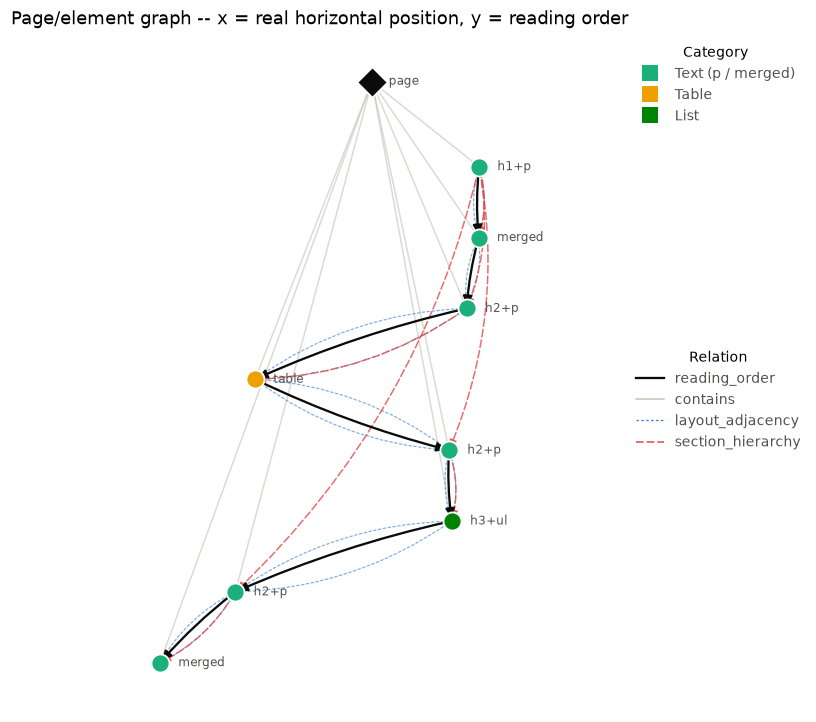

In [5]:
graph = build_graph(tiles, page_url=FIXTURE_URL, page_title="Page de démonstration")
print(f"{graph.number_of_nodes()} noeuds, {graph.number_of_edges()} arêtes")
print("Arêtes par relation :", dict(Counter(d["relation"] for _, _, d in graph.edges(data=True))))

fig, ax = plt.subplots(figsize=(7, 8))
plot_graph(graph, ax=ax)
plt.show()

In [6]:
# Rendu XML du graphe, tel que lu par le modèle lecteur (aperçu des 2 premiers éléments)
xml_str = graph_to_xml(graph)
print(xml_str[:750])

<?xml version="1.0" ?>
<page url="file:///Users/alexisfirome/Desktop/PDM/domgraph-rag/tests/fixtures/sample_page.html" title="Page de démonstration">
  <element id="tile_0000" tag="h1+p" state="inactive">Retrieval-Augmented Generation (page d'exemple) La génération augmentée par récupération (RAG) est une technique combinant un système de recherche d'information et un grand modèle de langage.</element>
  <element id="tile_0001" tag="merged" state="inactive">Elle permet de fournir au modèle un contexte externe pertinent au moment de la requête, plutôt que de compter uniquement sur ses paramètres appris.</element>
  <element id="tile_0002" tag="h2+p" state="inactive">Approches visuelles Certaines approches récentes, comme PixelRAG, proposent 


## Étape 4 — Sectionnement des pages trop longues (Phase 1e)

Une page démesurément longue (ex. un article Wikipedia à la discographie
interminable) est découpée en sections aux frontières de titres `h1`/`h2`
plutôt que tuilée d'un bloc — chaque section devient ensuite une unité de
travail indépendante (son propre noeud « page », son propre checkpoint dans
`scripts/build_dataset.py`).

La page de démonstration est bien trop petite pour déclencher ce
sectionnement en conditions réelles (`MAX_PAGE_HEIGHT_BEFORE_SPLIT` vaut
10x `MAX_TILE_HEIGHT`, soit ~20 000px) — on abaisse donc le seuil ici,
uniquement pour observer le mécanisme.

In [7]:
print(f"Page de démo surdimensionnée (seuil de production, {MAX_PAGE_HEIGHT_BEFORE_SPLIT}px) : "
      f"{is_oversized_page(elements)}")

# Seuil volontairement abaissé pour ce notebook : en production il vaut
# MAX_PAGE_HEIGHT_BEFORE_SPLIT (10x MAX_TILE_HEIGHT), cf. config.py.
sections = split_into_sections(elements, max_section_height=600)
print(f"\nAvec un seuil abaissé à 600px : {len(sections)} sections")
for s in sections:
    print(f"  section {s.index}: {len(s.elements):2d} éléments — titre={s.title[:45]!r}")

Page de démo surdimensionnée (seuil de production, 20480px) : False

Avec un seuil abaissé à 600px : 5 sections
  section 0:  3 éléments — titre="Retrieval-Augmented Generation (page d'exempl"
  section 1:  3 éléments — titre='Approches visuelles'
  section 2:  3 éléments — titre='Limites connues'
  section 3:  1 éléments — titre='Limites connues (suite 2)'
  section 4:  4 éléments — titre='Illustration'


Pour relier plusieurs pages entre elles (crawl à 1 saut le long des liens
hypertextes trouvés dans les tuiles de texte), voir `src/corpus_builder.py`
(`build_corpus_graph`) — non exécuté ici car il nécessite un accès réseau
réel ; démo sur une vraie page dans `notebooks/01_pipeline_playground.ipynb`.

## Étape 5 — Génération QA synthétique (Phase 2a)

En production, le VLM lit chaque tuile et pose une question dont la réponse
n'est visible que là (`QA_GENERATION_PROMPT`, réponse JSON `{"question":
..., "answer": ...}`, ou `SKIP` si la tuile n'est pas exploitable). Pour que
ce notebook tourne sans modèle ni réseau, `DemoVLMClient` ci-dessous simule
ce contrat à partir du texte déjà extrait par le DOM — remplacez-le par
`from src.vlm_client import VLMClient` (avec Ollama lancé, `ollama pull
qwen3-vl`) pour de vraies questions générées par le modèle.

In [8]:
class DemoVLMClient:
    """Remplace VLMClient pour ce notebook : aucun appel réseau ni modèle
    chargé, réponses déterministes dérivées du texte déjà extrait par le DOM
    -- juste pour illustrer le contrat attendu par qa_generation.py (JSON
    {question, answer}, ou SKIP si rien d'exploitable)."""

    def __init__(self, tiles):
        self._text_by_image_id = {id(t.image): t.text_preview for t in tiles}

    def ask(self, image, prompt, think=None):
        text = self._text_by_image_id.get(id(image), "").strip()
        if not text:
            return "SKIP"
        numbers = re.findall(r"\d+", text)
        answer = numbers[0] if numbers else text.split()[-1].strip(".,:;")
        question = f"Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ({text[:40]!r}...) ?"
        return json.dumps({"question": question, "answer": answer})


demo_client = DemoVLMClient(tiles)

# Dossier temporaire auto-nettoyé en fin de notebook -- en production,
# generate_qa_dataset() écrit directement dans data/qa_dataset/ (checkpointé).
demo_dir = Path(tempfile.mkdtemp(prefix="domgraph_demo_"))
image_paths = save_tile_images(tiles, page_slug="demo_page", images_dir=demo_dir / "images")
append_tiles_manifest(
    tiles, FIXTURE_URL, "demo_page", image_paths,
    manifest_path=demo_dir / "tiles_manifest.jsonl", images_root=demo_dir,
)

qa_pairs = []
for tile in tiles:
    qa = generate_qa_pair_for_tile(tile, demo_client, FIXTURE_URL, "demo_page", image_paths, images_root=demo_dir)
    status = f"question={qa.question!r} answer={qa.answer!r}" if qa else "SKIP (pas d'info exploitable)"
    print(f"  {tile.id} ({tile.dom_tag}): {status}")
    if qa:
        qa_pairs.append(qa)

print(f"\n{len(qa_pairs)}/{len(tiles)} tuiles ont produit une paire question/réponse")

  tile_0000 (h1+p): question='Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ("Retrieval-Augmented Generation (page d\'e"...) ?' answer='langage'
  tile_0001 (merged): question="Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Elle permet de fournir au modèle un cont'...) ?" answer='appris'
  tile_0002 (h2+p): question="Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Approches visuelles Certaines approches '...) ?" answer='brut'
  tile_0003 (table): question="Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Système\\tGranularité\\tBenchmark principal\\n'...) ?" answer='LongDocURL'
  tile_0004 (h2+p): question="Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Limites connues Un découpage en tuiles d'...) ?" answer='contenu'
  tile_0005 (h3+ul): question="Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Liste des problèmes identifiés Parser lo'...) ?" answer='2'
  tile_0006 (h2+p): SKIP (pas d'info exploitable

## Étape 6 — Hard-negative mining (Phase 2b)

Pour chaque paire (question, tuile positive), on sélectionne quelques tuiles
lexicalement proches (TF-IDF + cosinus) mais qui ne contiennent pas la
réponse : des négatifs « difficiles », plus utiles à l'entraînement
contrastif que des négatifs pris au hasard.

In [9]:
contrastive_examples = mine_hard_negatives(qa_pairs, tiles, n_negatives=2)
for ex in contrastive_examples:
    print(f"  Q: {ex.question!r}")
    print(f"     positif = {ex.positive_tile_id}   négatifs difficiles = {ex.hard_negative_tile_ids}")

  Q: 'Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ("Retrieval-Augmented Generation (page d\'e"...) ?'
     positif = tile_0000   négatifs difficiles = ['tile_0004', 'tile_0002']
  Q: "Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Elle permet de fournir au modèle un cont'...) ?"
     positif = tile_0001   négatifs difficiles = ['tile_0004', 'tile_0000']
  Q: "Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Approches visuelles Certaines approches '...) ?"
     positif = tile_0002   négatifs difficiles = ['tile_0004', 'tile_0000']
  Q: "Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Système\\tGranularité\\tBenchmark principal\\n'...) ?"
     positif = tile_0003   négatifs difficiles = ['tile_0004', 'tile_0000']
  Q: "Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ('Limites connues Un découpage en tuiles d'...) ?"
     positif = tile_0004   négatifs difficiles = ['tile_0002', 'tile_0000']
  Q: "Quel élément (chiffre 

## Étape 7 — Dataset contrastif PyTorch (Phase 2c)

`ContrastiveTileDataset` assemble les fichiers produits par les deux étapes
précédentes en exemples (question, image positive, images négatives),
directement consommables par une boucle d'entraînement PyTorch.

7 exemples contrastifs chargés


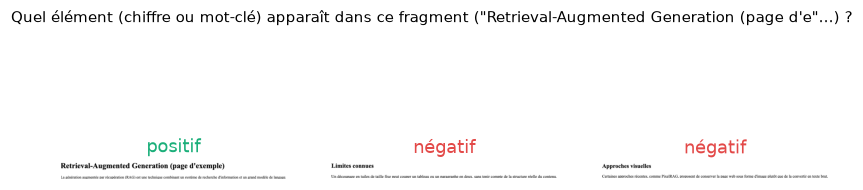

Batch collaté : {'questions': ['Quel élément (chiffre ou mot-clé) apparaît dans ce fragment ("Retrieval-Augmented Generation (page d\'e"...) ?'], 'tile_images': 3, 'positive_indices': 1}


In [10]:
examples_path = demo_dir / "contrastive_examples.jsonl"
save_contrastive_examples(contrastive_examples, examples_path)

dataset = ContrastiveTileDataset(
    contrastive_examples_path=examples_path,
    tiles_manifest_path=demo_dir / "tiles_manifest.jsonl",
    images_root=demo_dir,
)
print(f"{len(dataset)} exemples contrastifs chargés")

if len(dataset) > 0:
    item = dataset[0]
    n = 1 + len(item.negative_images)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    axes = [axes] if n == 1 else list(axes)
    axes[0].imshow(item.positive_image)
    axes[0].set_title("positif", color="#1baf7a")
    axes[0].axis("off")
    for ax, neg in zip(axes[1:], item.negative_images):
        ax.imshow(neg)
        ax.set_title("négatif", color="#e34948")
        ax.axis("off")
    fig.suptitle(item.question, fontsize=10)
    plt.show()

    batch = contrastive_collate_fn([item])
    print("Batch collaté :", {k: (v if k == "questions" else len(v)) for k, v in batch.items()})

## Étape 8 — Fine-tuning LoRA du lecteur (Phase 2d)

`src/lora_finetune.py` transforme le VLM lecteur (génératif) en encodeur de
similarité (prompt court + état caché du dernier token comme embedding), et
l'affine par LoRA — sur le LLM **et** la tour de vision (ViT) — avec une loss
InfoNCE : la tuile positive doit être plus proche de la question que les
négatifs difficiles minés à l'étape 6 (et que les positifs des *autres*
questions du batch). Non exécuté ici (nécessite `torch` + `transformers` +
`peft`, idéalement un GPU) :

```bash
python3 -m src.lora_finetune --epochs 3 --batch-size 4
```

## Étape 9 — Contrôleur d'évidence en ligne (Phase 3)

Chaque noeud élément part de l'état `inactive`. Pour une requête donnée, le
contrôleur active les noeuds les plus pertinents (TF-IDF + cosinus), puis
boucle en best-first sous budget : ouvrir le noeud actif le plus pertinent
(consomme le budget), activer ses voisins (`reading_order`, et au besoin
`links_to`/`continues` pour franchir une frontière de document), ou l'élaguer
s'il est sous le seuil. On interroge ici une question thématiquement liée au
contenu de la page de démonstration.

In [11]:
query = "Quelles sont les limites connues du tuilage à taille fixe ?"

# Graphe frais (state='inactive' partout) : run_evidence_controller modifie le graphe en place.
controller_graph = build_graph(tiles, page_url=FIXTURE_URL, page_title="Page de démonstration")
config = EvidenceControllerConfig(budget=4, top_k_seed=2, use_vlm=False)
log = run_evidence_controller(controller_graph, tiles, query, config)

for action in log:
    print(f"  [{action.step:2d}] {action.action:8s} {action.node_id:10s} "
          f"score={action.score:.3f}  ({action.state_before} -> {action.state_after})")

print("\nRépartition finale des états :", state_counts(controller_graph))
print("\nÉvidence retenue (tuiles 'opened', dans l'ordre de lecture) :\n" + collect_evidence(controller_graph))

  [ 0] seed     tile_0004  score=0.260  (inactive -> active)
  [ 1] seed     tile_0003  score=0.091  (inactive -> active)
  [ 2] open     tile_0004  score=0.260  (active -> opened)
  [ 3] open     tile_0003  score=0.091  (active -> opened)

Répartition finale des états : {'inactive': 6, 'active': 0, 'opened': 2, 'pruned': 0}

Évidence retenue (tuiles 'opened', dans l'ordre de lecture) :
Système	Granularité	Benchmark principal
Text RAG	Chunk de texte	NQ
PixelRAG	Tuile pixel (taille fixe)	SimpleQA
MAGE-RAG	Graphe multi-granulaire	LongDocURL

Limites connues Un découpage en tuiles de taille fixe peut couper un tableau ou un paragraphe en deux, sans tenir compte de la structure réelle du contenu.


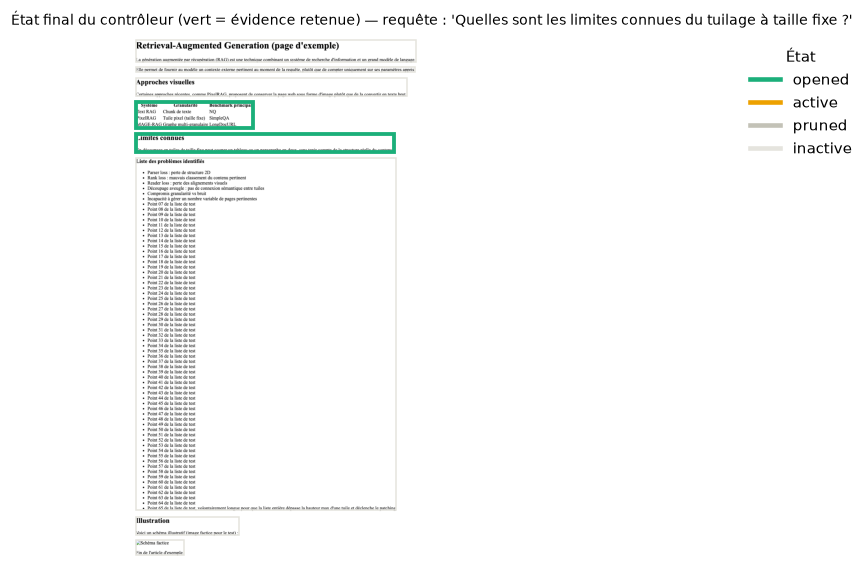

In [12]:
# Quelles tuiles le contrôleur a-t-il retenues comme évidence, superposées à la page ?
_STATE_COLORS = {"opened": "#1baf7a", "active": "#eda100", "pruned": "#c3c2b7", "inactive": "#e5e4de"}

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(Image.open(io.BytesIO(screenshot)).convert("RGB"))
for tile in tiles:
    state = controller_graph.nodes[tile.id]["state"]
    color = _STATE_COLORS[state]
    ax.add_patch(plt.Rectangle(
        (tile.x, tile.y), tile.width, tile.height,
        linewidth=2.5 if state == "opened" else 1, edgecolor=color, facecolor="none",
    ))
ax.set_title(f"État final du contrôleur (vert = évidence retenue) — requête : {query!r}", fontsize=9)
ax.axis("off")
handles = [plt.Line2D([0], [0], color=c, lw=3, label=s) for s, c in _STATE_COLORS.items()]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, title="État")
plt.show()

## Étape 10 — Site de démo (Phase 3, `webapp/`)

`webapp/backend/pipeline.py` enchaîne exactement les étapes 1 à 9 pour une
URL et une question posées via un formulaire web : extraction DOM -> tuilage
-> graphe -> contrôleur d'évidence (`use_vlm=True`, chaque tuile ouverte est
relue par le VLM) -> synthèse de la réponse finale par le VLM à partir de
l'évidence rassemblée. Le frontend affiche la réponse, le graphe interactif
(cytoscape.js) et les liens Wikipedia rencontrés (avec un badge pour ceux
portés par une tuile retenue comme évidence). Non lancé ici :

```bash
ollama pull qwen3-vl
uvicorn webapp.backend.main:app --reload
# puis ouvrir http://127.0.0.1:8000/
```

## Pour aller plus loin

- **`notebooks/01_pipeline_playground.ipynb`** — la même pipeline sur une
  vraie page (Wikipedia par défaut), avec un graphe interactif pyvis.
- **`scripts/build_dataset.py`** — construit le vrai jeu de données QA/
  contrastif à l'échelle d'un corpus, avec reprise sur erreur (checkpoint).
- **`scripts/build_multihop_dataset.py`** — questions multi-pages à partir de
  HotpotQA (`src/multihop_qa.py`), pour évaluer le graphe au-delà du cas
  mono-tuile (Phase 4).
- **`scripts/eval_*.py`, `scripts/dom_vs_grid_experiment.py`** — ablations et
  évaluations (retrieval, contrôleur, bout-en-bout) utilisées pour produire
  les figures de `graphiques/`.
- **`webapp/`** — site de démo complet (voir étape 10).
- **`paper/`** — rédaction du rapport.

In [13]:
# Nettoyage du dossier temporaire créé aux étapes 5-7 (aucune trace laissée sur le disque).
shutil.rmtree(demo_dir, ignore_errors=True)
print("Dossier temporaire nettoyé :", demo_dir)

Dossier temporaire nettoyé : /var/folders/qv/jxqksgr511n2kd5_v801s5vc0000gn/T/domgraph_demo_8p3xpnvi
